In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL

from scipy import stats
from scipy import optimize
import seaborn as sns; sns.set() # set default plot styles
import emcee
import statsmodels.api as sm
import corner
import time
from scipy.optimize import curve_fit
from datetime import datetime, timedelta


In [2]:
#Load data

#  Reaad in MIRA data
file = '/Users/alex/Dropbox/MIRA_Madagascar_Project/Final_Scripts/mira_cleaned.csv'
mira = pd.read_csv(file, delimiter=',') 
print(mira.columns)

# Read in EVI
c1e=pd.read_csv('/Users/alex/Dropbox/MIRA_Madagascar_Project/c1_evi_ts.csv')
c2e=pd.read_csv('/Users/alex/Dropbox/MIRA_Madagascar_Project/c2_evi_ts.csv')
c3e=pd.read_csv('/Users/alex/Dropbox/MIRA_Madagascar_Project/c3_evi_ts.csv')
c4e=pd.read_csv('/Users/alex/Dropbox/MIRA_Madagascar_Project/c4_evi_ts.csv')
c5e=pd.read_csv('/Users/alex/Dropbox/MIRA_Madagascar_Project/c5_evi_ts.csv')
c6e=pd.read_csv('/Users/alex/Dropbox/MIRA_Madagascar_Project/c6_evi_ts.csv')

Index(['id_hh', 'year', 'month', 'day', 'Maize', 'Sorghum', 'Millet', 'Rice',
       'Cassava Root', 'Cassava Leaves', 'Sweet Potato', 'Other Tubers',
       'Peanuts', 'Cowpeas', 'Beans', 'Dolique', 'Other Legumues', 'item_14',
       'green/white cactus', 'red cactus', 'vegetables', 'melons',
       'other fruit', 'cactus leaves', 'other leaves', 'beef', 'other meat',
       'milk products', 'item 25', 'watermelon', 'peas', 'fish products',
       'other', 'eggs', 'sugar', 'serial_date', 'lat', 'lon', 'commune'],
      dtype='object')


In [3]:
# Convert EVI time from julian dayz
print(c1e)

from datetime import datetime, timedelta

def matlab_datenum_to_datetime(dn):
    return datetime.fromordinal(int(dn)) + timedelta(days=dn % 1) - timedelta(days=366)

for df in [c1e, c2e, c3e, c4e, c5e, c6e]:
    df["date"] = df.iloc[:, 0].apply(matlab_datenum_to_datetime)

commune_evis = pd.DataFrame({
    "date": c1e["date"],
    "c1": c1e.iloc[:, 1],
    "c2": c2e.iloc[:, 1],
    "c3": c3e.iloc[:, 1],
    "c4": c4e.iloc[:, 1],
    "c5": c5e.iloc[:, 1],
    "c6": c6e.iloc[:, 1],
})


commune_evis["date"] = pd.to_datetime(commune_evis["date"])

commune_evis_monthly = (
    commune_evis
    .set_index("date")
    .sort_index()
    .resample("MS")
    .mean()
    .reset_index() 
)

print(commune_evis_monthly.head())


commune_evis_filtered = commune_evis_monthly[
    (commune_evis_monthly["date"] >= "2018-07-01") &
    (commune_evis_monthly["date"] <= "2022-03-31")
].copy()

commune_evis_filtered["month"] = commune_evis_filtered["date"].dt.month

print(commune_evis_filtered.head())




     evi_time  c1_mean_evi
0      730534     0.231631
1      730550     0.229001
2      730566     0.220855
3      730582     0.210937
4      730598     0.203148
..        ...          ...
537    739063     0.230008
538    739079     0.216009
539    739095     0.207626
540    739111     0.203804
541    739127     0.182003

[542 rows x 2 columns]
        date        c1        c2        c3        c4        c5        c6
0 2000-02-01  0.231631  0.227861  0.251910  0.202052  0.221681  0.243103
1 2000-03-01  0.224928  0.220543  0.236679  0.192610  0.210423  0.227243
2 2000-04-01  0.207043  0.208685  0.213930  0.187668  0.203930  0.210679
3 2000-05-01  0.211679  0.214387  0.230394  0.202348  0.246782  0.253878
4 2000-06-01  0.192535  0.198389  0.240129  0.236062  0.282045  0.256344
          date        c1        c2        c3        c4        c5        c6  \
221 2018-07-01  0.177467  0.183026  0.208305  0.216205  0.225665  0.203977   
222 2018-08-01  0.159191  0.166450  0.196014  0.217059  0.

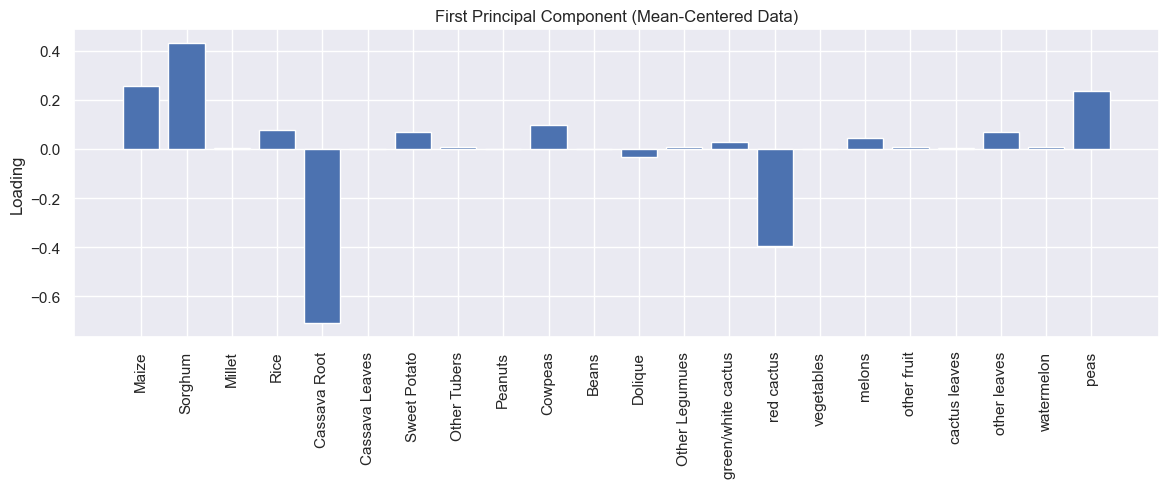

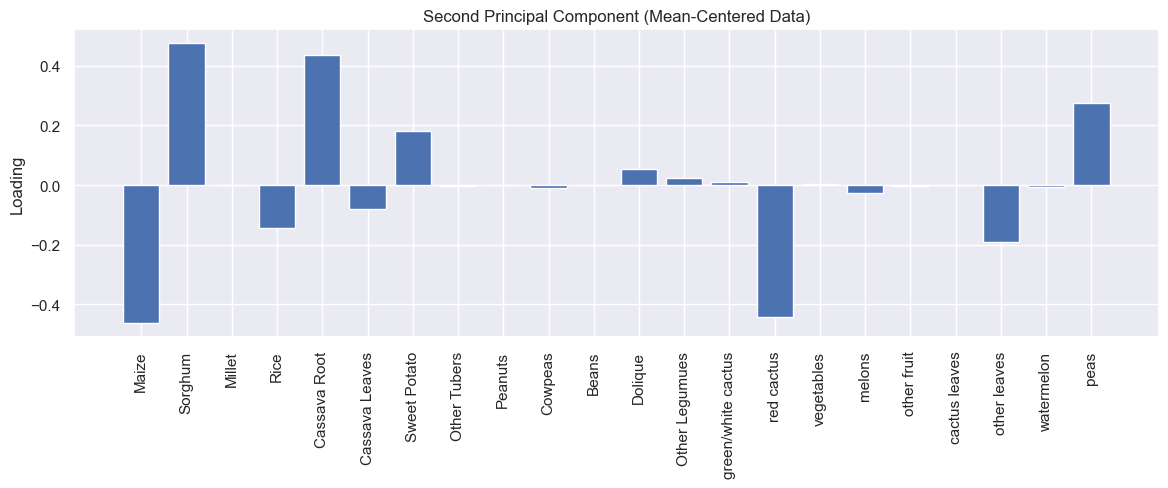

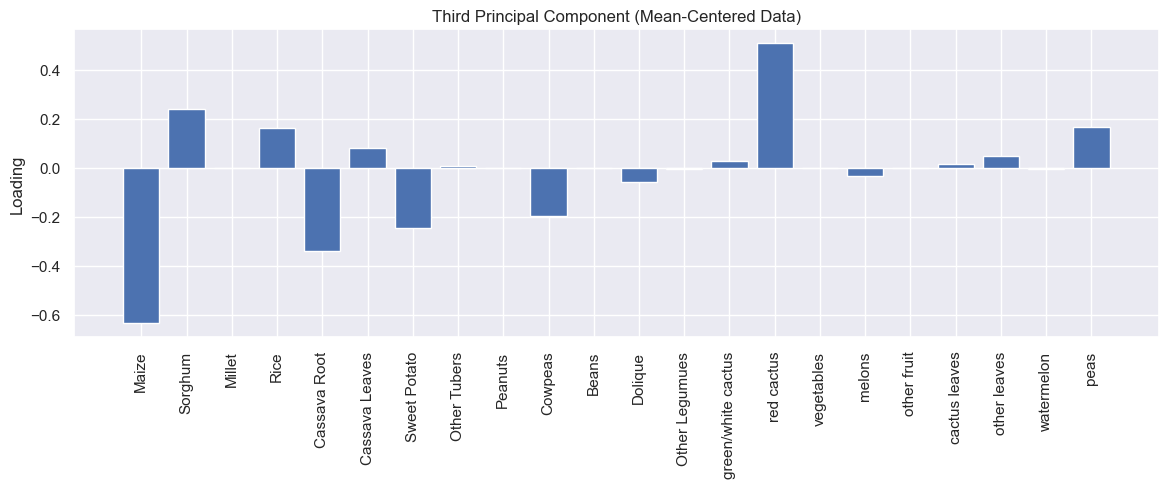

In [4]:
# Prep data for SVD
#Replace nan by column averages for the appropriate commune 
#Pull food columns
food_columns = ['Maize', 'Sorghum', 'Millet', 'Rice', 'Cassava Root', 'Cassava Leaves', 'Sweet Potato',
                'Other Tubers', 'Peanuts', 'Cowpeas', 'Beans', 'Dolique', 'Other Legumues', 'green/white cactus',
                'red cactus', 'vegetables', 'melons', 'other fruit', 'cactus leaves', 'other leaves',
                'watermelon', 'peas']


mira[food_columns] = (
    mira.groupby('commune')[food_columns]
      .transform(lambda x: x.fillna(x.mean()))
)

# Create a df with just foods
ndvi_foods = mira[food_columns]

# Mean centering
ndvi_foods_centered = (
    mira
    .groupby('commune')[food_columns]
    .transform(lambda x: x - x.mean())
)


# Perform SVD on the mean-centered data
U, Sigma, VT = np.linalg.svd(ndvi_foods_centered, full_matrices=False)


# Plot the first principal component
plt.figure(figsize=[14,4])
plt.bar(food_columns, VT[0, :])  # First principal component
plt.title('First Principal Component (Mean-Centered Data)')
plt.xticks(rotation=90)
plt.ylabel('Loading')
plt.grid(True)
plt.show()

# Plot the second principal component
plt.figure(figsize=[14,4])
plt.bar(food_columns, VT[1, :])  # Second principal component
plt.title('Second Principal Component (Mean-Centered Data)')
plt.xticks(rotation=90)
plt.ylabel('Loading')
plt.grid(True)
plt.show()

# Plot the third principal component
plt.figure(figsize=[14,4])
plt.bar(food_columns, VT[2, :])  # Third principal component
plt.title('Third Principal Component (Mean-Centered Data)')
plt.xticks(rotation=90)
plt.ylabel('Loading')
plt.grid(True)
plt.show()

# monthly_averages.to_csv('monthly_averages.csv', index=False)  # index=False to not include the DataFrame index in the file


In [5]:
# Project 1st PCA back onto the data
pc1 = VT[0, :]

projected_data = np.dot(ndvi_foods_centered, pc1)

# Add back to MIRA data
mira['dc1'] = projected_data

# print(mira['dc1'])
# Print the Variance Explained
total_variance = np.sum(Sigma**2)  # Sum of squares of all singular values
variance_explained_first_PCA = (Sigma[0]**2) / total_variance  # Proportion for the first singular value

print("Variance explained by the first principal component: {:.2f}%".format(variance_explained_first_PCA * 100))




Variance explained by the first principal component: 17.78%


In [6]:
#Plot by communes 
# Add year month var to df
# avg ndvi by year month 
mira['YearMonth'] = pd.to_datetime(mira[['year', 'month']].assign(day=1))

            id_hh    year  month   day  Maize  Sorghum  Millet  Rice  \
0  161_Asit_99540  2018.0    8.0   1.0    0.0      0.0     0.0   0.0   
1  161_Asit_99540  2018.0    9.0  22.0    1.0      0.0     0.0   0.0   
2  161_Asit_99540  2018.0   10.0   1.0    1.0      0.0     0.0   0.0   
3  161_Asit_99540  2018.0   11.0   9.0    1.0      0.0     0.0   0.0   
4  161_Asit_99540  2018.0   12.0  21.0    0.0      1.0     0.0   0.0   

   Cassava Root  Cassava Leaves  ...  fish products  other  eggs  sugar  \
0           0.0             0.0  ...            0.0    NaN   NaN    NaN   
1           1.0             0.0  ...            0.0    1.0   0.0    0.0   
2           0.0             0.0  ...            0.0    0.0   0.0    0.0   
3           0.0             0.0  ...            0.0    0.0   0.0    0.0   
4           0.0             0.0  ...            0.0    0.0   0.0    0.0   

   serial_date        lat        lon  commune       dc1  YearMonth  
0     737273.0 -25.272051  44.601728        1  

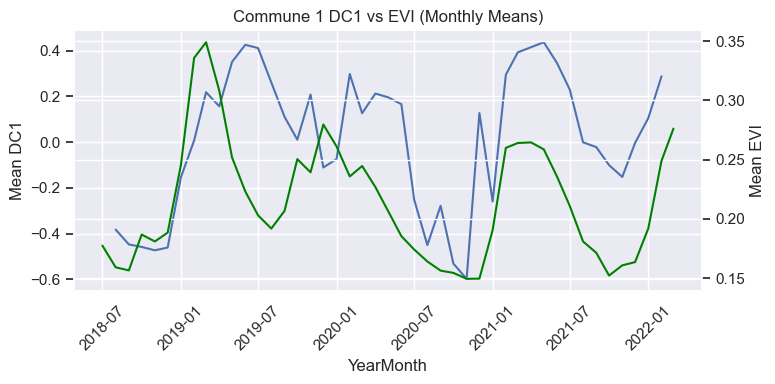

In [7]:
# Commune 1

c1_mira = mira[mira['commune']==1]
avg_dc1_c1 = c1_mira.groupby('YearMonth')['dc1'].mean()

print(c1_mira.head())
# print(avg_dc1_c1.head())

# Left ax
fig, ax1 = plt.subplots(figsize=(8,4))
ax1.plot(avg_dc1_c1)
ax1.set_ylabel('Mean DC1')
ax1.set_xlabel('YearMonth')
ax1.tick_params(axis='x', rotation=45)

print(c1e)

# Right ax
ax2 = ax1.twinx()
ax2.plot(commune_evis_filtered['date'], commune_evis_filtered['c1'], color='green')
ax2.set_ylabel('Mean EVI')

plt.title('Commune 1 DC1 vs EVI (Monthly Means)')
plt.tight_layout()
plt.show()



In [8]:
# # COMMUNE 1 Models
# print(avg_dc1_c1.head())
# print(commune_evis_filtered.head())


# # # Setting index for join
# df1_indexed = avg_dc1.to_frame(name="dc1")                    
# df2_indexed = commune_evis_filtered.set_index("date")

# # Merge datasets for ols
# c1_df = df1_indexed.join(df2_indexed, how="inner")

# print(c1_df.head())

import statsmodels.formula.api as smf

# #simple ols
# model = smf.ols('dc1 ~ c1', data=c1_df).fit()

# # Print results
# print(model.summary())

# ##### Month fixed effect

# c1_mdf = smf.ols("dc1 ~ c1 + C(month)", data=c1_df).fit()

# print('C1 Month Effect Model')
# print(c1_mdf.summary())

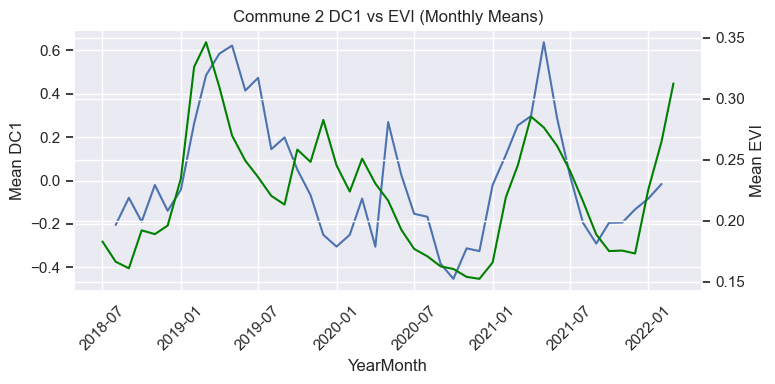

In [9]:
# Commune 2

c2_mira = mira[mira['commune']==2]
avg_dc1_c2 = c2_mira.groupby('YearMonth')['dc1'].mean()


# print(avg_dc1)

# Left ax
fig, ax1 = plt.subplots(figsize=(8,4))
ax1.plot(avg_dc1_c2)
ax1.set_ylabel('Mean DC1')
ax1.set_xlabel('YearMonth')
ax1.tick_params(axis='x', rotation=45)

# Right ax
ax2 = ax1.twinx()
ax2.plot(commune_evis_filtered['date'], commune_evis_filtered['c2'], color='green')
ax2.set_ylabel('Mean EVI')

plt.title('Commune 2 DC1 vs EVI (Monthly Means)')
plt.tight_layout()
plt.show()

In [10]:
# COMMUNE 2 Models
print(avg_dc1_c2.head())
print(commune_evis_filtered.head())


# # Setting index for join
df1_indexed = avg_dc1_c2.to_frame(name="dc1")                    
df2_indexed = commune_evis_filtered.set_index("date")

# Merge datasets for ols
c2_df = df1_indexed.join(df2_indexed, how="inner")

print(c2_df.head())


#simple ols
model = smf.ols('dc1 ~ c2', data=c2_df).fit()

# Print results
print(model.summary())

##### Month fixed effect

c2_mdf = smf.ols("dc1 ~ c2 + C(month)", data=c2_df).fit()

print('C2 Month Effect Model')
print(c2_mdf.summary())

YearMonth
2018-08-01   -0.204701
2018-09-01   -0.079508
2018-10-01   -0.189810
2018-11-01   -0.020510
2018-12-01   -0.139395
Name: dc1, dtype: float64
          date        c1        c2        c3        c4        c5        c6  \
221 2018-07-01  0.177467  0.183026  0.208305  0.216205  0.225665  0.203977   
222 2018-08-01  0.159191  0.166450  0.196014  0.217059  0.205149  0.183901   
223 2018-09-01  0.156572  0.161001  0.184740  0.214333  0.209592  0.193471   
224 2018-10-01  0.186825  0.192123  0.229113  0.258431  0.258384  0.253459   
225 2018-11-01  0.181006  0.189019  0.231775  0.250393  0.276671  0.266765   

     month  
221      7  
222      8  
223      9  
224     10  
225     11  
                 dc1        c1        c2        c3        c4        c5  \
2018-08-01 -0.204701  0.159191  0.166450  0.196014  0.217059  0.205149   
2018-09-01 -0.079508  0.156572  0.161001  0.184740  0.214333  0.209592   
2018-10-01 -0.189810  0.186825  0.192123  0.229113  0.258431  0.258384   
2018-1

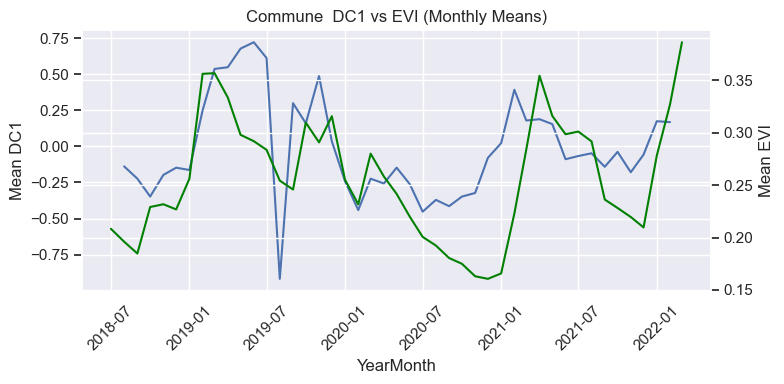

In [11]:
# Commune 3
c3_mira = mira[mira['commune']==3]
avg_dc1_c3 = c3_mira.groupby('YearMonth')['dc1'].mean()


# print(avg_dc1)

# Left ax
fig, ax1 = plt.subplots(figsize=(8,4))
ax1.plot(avg_dc1_c3)
ax1.set_ylabel('Mean DC1')
ax1.set_xlabel('YearMonth')
ax1.tick_params(axis='x', rotation=45)

# Right ax
ax2 = ax1.twinx()
ax2.plot(commune_evis_filtered['date'], commune_evis_filtered['c3'], color='green')
ax2.set_ylabel('Mean EVI')

plt.title('Commune  DC1 vs EVI (Monthly Means)')
plt.tight_layout()
plt.show()

In [12]:
# COMMUNE 3 Models
print(avg_dc1_c3.head())
print(commune_evis_filtered.head())


# # Setting index for join
df1_indexed = avg_dc1_c3.to_frame(name="dc1")                    
df2_indexed = commune_evis_filtered.set_index("date")

# Merge datasets for ols
c3_df = df1_indexed.join(df2_indexed, how="inner")

print(c3_df.head())


#simple ols
model = smf.ols('dc1 ~ c3', data=c3_df).fit()

# Print results
print(model.summary())

##### Month fixed effect

c3_mdf = smf.ols("dc1 ~ c3 + C(month)", data=c3_df).fit()

print('C3 Month Effect Model')
print(c3_mdf.summary())

YearMonth
2018-08-01   -0.138540
2018-09-01   -0.223367
2018-10-01   -0.347551
2018-11-01   -0.197510
2018-12-01   -0.147398
Name: dc1, dtype: float64
          date        c1        c2        c3        c4        c5        c6  \
221 2018-07-01  0.177467  0.183026  0.208305  0.216205  0.225665  0.203977   
222 2018-08-01  0.159191  0.166450  0.196014  0.217059  0.205149  0.183901   
223 2018-09-01  0.156572  0.161001  0.184740  0.214333  0.209592  0.193471   
224 2018-10-01  0.186825  0.192123  0.229113  0.258431  0.258384  0.253459   
225 2018-11-01  0.181006  0.189019  0.231775  0.250393  0.276671  0.266765   

     month  
221      7  
222      8  
223      9  
224     10  
225     11  
                 dc1        c1        c2        c3        c4        c5  \
2018-08-01 -0.138540  0.159191  0.166450  0.196014  0.217059  0.205149   
2018-09-01 -0.223367  0.156572  0.161001  0.184740  0.214333  0.209592   
2018-10-01 -0.347551  0.186825  0.192123  0.229113  0.258431  0.258384   
2018-1

     evi_time  c1_mean_evi       date
0      730534     0.231631 2000-02-18
1      730550     0.229001 2000-03-05
2      730566     0.220855 2000-03-21
3      730582     0.210937 2000-04-06
4      730598     0.203148 2000-04-22
..        ...          ...        ...
537    739063     0.230008 2023-06-26
538    739079     0.216009 2023-07-12
539    739095     0.207626 2023-07-28
540    739111     0.203804 2023-08-13
541    739127     0.182003 2023-08-29

[542 rows x 3 columns]


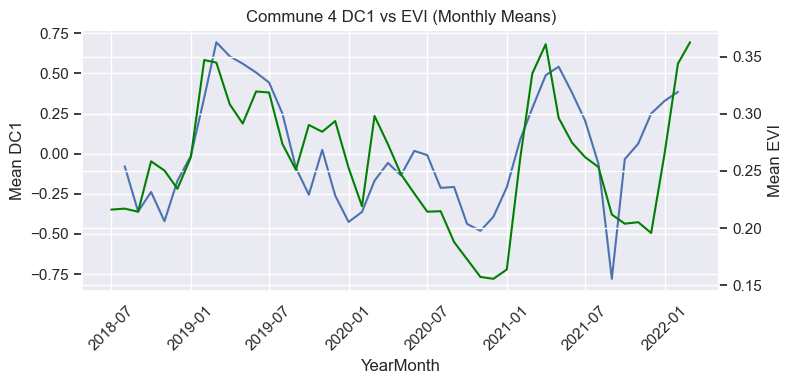

In [13]:
# Commune 4

c4_mira = mira[mira['commune']==4]
avg_dc1_c4 = c4_mira.groupby('YearMonth')['dc1'].mean()


# print(avg_dc1)

# Left ax
fig, ax1 = plt.subplots(figsize=(8,4))
ax1.plot(avg_dc1_c4)
ax1.set_ylabel('Mean DC1')
ax1.set_xlabel('YearMonth')
ax1.tick_params(axis='x', rotation=45)

print(c1e)

# Right ax
ax2 = ax1.twinx()
ax2.plot(commune_evis_filtered['date'], commune_evis_filtered['c4'], color='green')
ax2.set_ylabel('Mean EVI')

plt.title('Commune 4 DC1 vs EVI (Monthly Means)')
plt.tight_layout()
plt.show()

In [14]:
# COMMUNE 4 Models
print(avg_dc1_c4.head())
print(commune_evis_filtered.head())


# # Setting index for join
df1_indexed = avg_dc1_c4.to_frame(name="dc1")                    
df2_indexed = commune_evis_filtered.set_index("date")

# Merge datasets for ols
c4_df = df1_indexed.join(df2_indexed, how="inner")

print(c4_df.head())

#simple ols
model = smf.ols('dc1 ~ c4', data=c4_df).fit()

# Print results
print(model.summary())

##### Month fixed effect

c4_mdf = smf.ols("dc1 ~ c4 + C(month)", data=c4_df).fit()

print('C4 Month Effect Model')
print(c4_mdf.summary())

YearMonth
2018-08-01   -0.078466
2018-09-01   -0.360402
2018-10-01   -0.238635
2018-11-01   -0.421033
2018-12-01   -0.168522
Name: dc1, dtype: float64
          date        c1        c2        c3        c4        c5        c6  \
221 2018-07-01  0.177467  0.183026  0.208305  0.216205  0.225665  0.203977   
222 2018-08-01  0.159191  0.166450  0.196014  0.217059  0.205149  0.183901   
223 2018-09-01  0.156572  0.161001  0.184740  0.214333  0.209592  0.193471   
224 2018-10-01  0.186825  0.192123  0.229113  0.258431  0.258384  0.253459   
225 2018-11-01  0.181006  0.189019  0.231775  0.250393  0.276671  0.266765   

     month  
221      7  
222      8  
223      9  
224     10  
225     11  
                 dc1        c1        c2        c3        c4        c5  \
2018-08-01 -0.078466  0.159191  0.166450  0.196014  0.217059  0.205149   
2018-09-01 -0.360402  0.156572  0.161001  0.184740  0.214333  0.209592   
2018-10-01 -0.238635  0.186825  0.192123  0.229113  0.258431  0.258384   
2018-1

     evi_time  c1_mean_evi       date
0      730534     0.231631 2000-02-18
1      730550     0.229001 2000-03-05
2      730566     0.220855 2000-03-21
3      730582     0.210937 2000-04-06
4      730598     0.203148 2000-04-22
..        ...          ...        ...
537    739063     0.230008 2023-06-26
538    739079     0.216009 2023-07-12
539    739095     0.207626 2023-07-28
540    739111     0.203804 2023-08-13
541    739127     0.182003 2023-08-29

[542 rows x 3 columns]


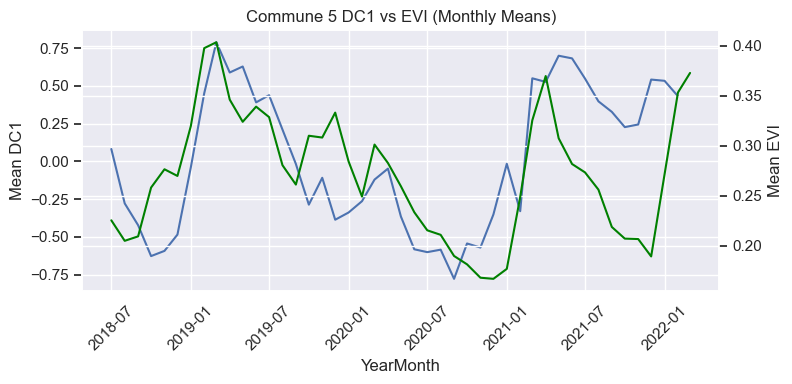

In [15]:
# Commune 5

c5_mira = mira[mira['commune']==5]
avg_dc1_c5 = c5_mira.groupby('YearMonth')['dc1'].mean()


# print(avg_dc1)

# Left ax
fig, ax1 = plt.subplots(figsize=(8,4))
ax1.plot(avg_dc1_c5)
ax1.set_ylabel('Mean DC1')
ax1.set_xlabel('YearMonth')
ax1.tick_params(axis='x', rotation=45)

print(c1e)

# Right ax
ax2 = ax1.twinx()
ax2.plot(commune_evis_filtered['date'], commune_evis_filtered['c5'], color='green')
ax2.set_ylabel('Mean EVI')

plt.title('Commune 5 DC1 vs EVI (Monthly Means)')
plt.tight_layout()
plt.show()

In [16]:
# COMMUNE 5 Models
print(avg_dc1_c5.head())
print(commune_evis_filtered.head())


# # Setting index for join
df1_indexed = avg_dc1_c5.to_frame(name="dc1")                    
df2_indexed = commune_evis_filtered.set_index("date")

# Merge datasets for ols
c5_df = df1_indexed.join(df2_indexed, how="inner")

print(c5_df.head())

import statsmodels.formula.api as smf

#simple ols
model = smf.ols('dc1 ~ c5', data=c5_df).fit()

# Print results
print(model.summary())

##### Month fixed effect

c5_mdf = smf.ols("dc1 ~ c5 + C(month)", data=c2_df).fit()

print('C5 Month Effect Model')
print(c5_mdf.summary())

YearMonth
2018-07-01    0.082015
2018-08-01   -0.278346
2018-09-01   -0.422754
2018-10-01   -0.627460
2018-11-01   -0.593099
Name: dc1, dtype: float64
          date        c1        c2        c3        c4        c5        c6  \
221 2018-07-01  0.177467  0.183026  0.208305  0.216205  0.225665  0.203977   
222 2018-08-01  0.159191  0.166450  0.196014  0.217059  0.205149  0.183901   
223 2018-09-01  0.156572  0.161001  0.184740  0.214333  0.209592  0.193471   
224 2018-10-01  0.186825  0.192123  0.229113  0.258431  0.258384  0.253459   
225 2018-11-01  0.181006  0.189019  0.231775  0.250393  0.276671  0.266765   

     month  
221      7  
222      8  
223      9  
224     10  
225     11  
                 dc1        c1        c2        c3        c4        c5  \
2018-07-01  0.082015  0.177467  0.183026  0.208305  0.216205  0.225665   
2018-08-01 -0.278346  0.159191  0.166450  0.196014  0.217059  0.205149   
2018-09-01 -0.422754  0.156572  0.161001  0.184740  0.214333  0.209592   
2018-1

     evi_time  c1_mean_evi       date
0      730534     0.231631 2000-02-18
1      730550     0.229001 2000-03-05
2      730566     0.220855 2000-03-21
3      730582     0.210937 2000-04-06
4      730598     0.203148 2000-04-22
..        ...          ...        ...
537    739063     0.230008 2023-06-26
538    739079     0.216009 2023-07-12
539    739095     0.207626 2023-07-28
540    739111     0.203804 2023-08-13
541    739127     0.182003 2023-08-29

[542 rows x 3 columns]


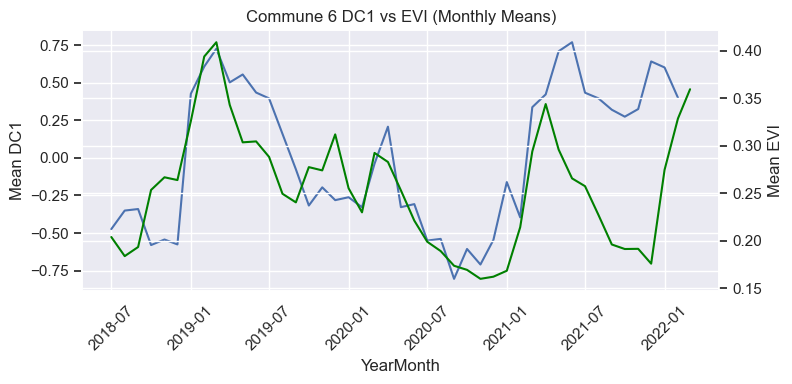

In [17]:
# Commune 6

c6_mira = mira[mira['commune']==6]
avg_dc1_c6 = c6_mira.groupby('YearMonth')['dc1'].mean()


# print(avg_dc1)

# Left ax
fig, ax1 = plt.subplots(figsize=(8,4))
ax1.plot(avg_dc1_c6)
ax1.set_ylabel('Mean DC1')
ax1.set_xlabel('YearMonth')
ax1.tick_params(axis='x', rotation=45)

print(c1e)

# Right ax
ax2 = ax1.twinx()
ax2.plot(commune_evis_filtered['date'], commune_evis_filtered['c6'], color='green')
ax2.set_ylabel('Mean EVI')

plt.title('Commune 6 DC1 vs EVI (Monthly Means)')
plt.tight_layout()
plt.show()

In [18]:
# COMMUNE 6 Models
print(avg_dc1_c6.head())
print(commune_evis_filtered.head())


# # Setting index for join
df1_indexed = avg_dc1_c6.to_frame(name="dc1")                    
df2_indexed = commune_evis_filtered.set_index("date")

# Merge datasets for ols
c6_df = df1_indexed.join(df2_indexed, how="inner")

print(c6_df.head())

import statsmodels.formula.api as smf

#simple ols
model = smf.ols('dc1 ~ c6', data=c6_df).fit()

# Print results
print(model.summary())

##### Month fixed effect

c6_mdf = smf.ols("dc1 ~ c6 + C(month)", data=c6_df).fit()

print('C6 Month Effect Model')
print(c6_mdf.summary())

YearMonth
2018-07-01   -0.473809
2018-08-01   -0.350653
2018-09-01   -0.340535
2018-10-01   -0.580018
2018-11-01   -0.543137
Name: dc1, dtype: float64
          date        c1        c2        c3        c4        c5        c6  \
221 2018-07-01  0.177467  0.183026  0.208305  0.216205  0.225665  0.203977   
222 2018-08-01  0.159191  0.166450  0.196014  0.217059  0.205149  0.183901   
223 2018-09-01  0.156572  0.161001  0.184740  0.214333  0.209592  0.193471   
224 2018-10-01  0.186825  0.192123  0.229113  0.258431  0.258384  0.253459   
225 2018-11-01  0.181006  0.189019  0.231775  0.250393  0.276671  0.266765   

     month  
221      7  
222      8  
223      9  
224     10  
225     11  
                 dc1        c1        c2        c3        c4        c5  \
2018-07-01 -0.473809  0.177467  0.183026  0.208305  0.216205  0.225665   
2018-08-01 -0.350653  0.159191  0.166450  0.196014  0.217059  0.205149   
2018-09-01 -0.340535  0.156572  0.161001  0.184740  0.214333  0.209592   
2018-1

In [19]:
c4_df

,dc1,c1,c2,c3,c4,c5,c6,month
2018-08-01,-0.078466,0.159191,0.166450,0.196014,0.217059,0.205149,0.183901,8
2018-09-01,-0.360402,0.156572,0.161001,0.184740,0.214333,0.209592,0.193471,9
2018-10-01,-0.238635,0.186825,0.192123,0.229113,0.258431,0.258384,0.253459,10
2018-11-01,-0.421033,0.181006,0.189019,0.231775,0.250393,0.276671,0.266765,11
2018-12-01,-0.168522,0.188465,0.196074,0.226826,0.234397,0.270003,0.263849,12
2019-01-01,-0.013853,0.245470,0.234736,0.256162,0.262008,0.319913,0.325758,1
2019-02-01,0.350128,0.335857,0.326108,0.356283,0.347056,0.397760,0.393706,2
2019-03-01,0.694831,0.349104,0.346352,0.356889,0.344790,0.403667,0.408710,3
2019-04-01,0.607471,0.308231,0.309876,0.333745,0.308382,0.346284,0.342843,4
2019-05-01,0.561267,0.251844,0.269822,0.298032,0.291460,0.324156,0.303496,5


In [28]:
from sklearn.decomposition import PCA


np.random.seed(123)

N, M = ndvi_foods_centered.shape
B = 500  # number of mcmc trials

pc1_null = np.zeros(B)

for b in range(B):
    # White-noise matrix with same dimensions
    X_null = np.random.normal(0, 1, size=(N, M))
    
    # Standardize
    X_null_std = (X_null - X_null.mean(axis=0))#mean center the data
    
    # PCA
    pca_null = PCA()
    pca_null.fit(X_null_std)
    
    # PC1 variance fraction
    pc1_null[b] = pca_null.explained_variance_ratio_[0]

# Summary statistics
mean_null = pc1_null.mean()
quant_null = np.quantile(pc1_null, [0.025, 0.975])

mean_null_percent = 100 * mean_null
quant_null_percent = 100 * quant_null

print(mean_null_percent) 
print(quant_null_percent)

dc1_var_real = variance_explained_first_PCA


4.8036512489003
[4.76586646 4.85056084]


In [26]:
p_empirical = np.mean(pc1_null >= dc1_var_real)
p_empirical


0.0

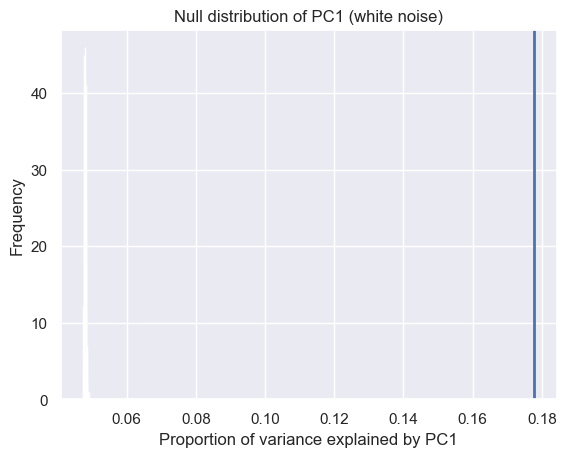

In [22]:
plt.hist(pc1_null, bins=30)
plt.axvline(dc1_var_real, linewidth=2)
plt.xlabel("Proportion of variance explained by PC1")
plt.ylabel("Frequency")
plt.title("Null distribution of PC1 (white noise)")
plt.show()


In [29]:
# North's rule check
pca = PCA().fit(ndvi_foods_centered)

# Eigenvalues of the correlation/covariance matrix (depending on preprocessing)
# In sklearn, explained_variance_ are the eigenvalues of the sample covariance of X_std
lam = pca.explained_variance_          # length M
lam1, lam2 = lam[0], lam[1]

# Choose effective sample size (start with Neff = N as a baseline)
Neff = N

delta_lam1 = lam1 * np.sqrt(2 / Neff)
gap12 = lam1 - lam2

print(f"lambda1 = {lam1:.6f}")
print(f"lambda2 = {lam2:.6f}")
print(f"gap (lambda1-lambda2) = {gap12:.6f}")
print(f"North delta_lambda1 ≈ {delta_lam1:.6f}")
print(f"Distinct by North? {gap12 > delta_lam1}")


lambda1 = 0.261272
lambda2 = 0.212307
gap (lambda1-lambda2) = 0.048965
North delta_lambda1 ≈ 0.002440
Distinct by North? True
